## 1. Dataset Preparation

Before constructing predictive features, the cleaned datasets need to be prepared and integrated.

The Rossmann dataset contains three main components:

- Training data: historical daily sales records with the target variable (`Sales`) and historical customer information (`Customers`).
- Test data: future daily records where sales need to be predicted.
- Store information: static attributes describing each store.

The store-level information is merged into both training and testing datasets because these attributes are available before prediction and can provide additional information about store performance.

The prediction task is defined as:

$$
Sales_t = f(X_t)
$$

where:

- \(Sales_t\) represents the sales value on day \(t\).
- \(X_t\) represents the available information used for prediction.

A key consideration in this project is that the test dataset does not contain same-day customer numbers. Although `Customers` is strongly related to `Sales` in historical data, it cannot be directly used as a predictive feature because it is unavailable during the actual prediction stage.

Therefore:

- `Customers` is retained in the training dataset for exploratory analysis and historical feature construction.
- Same-day `Customers` will not be included in the final model input.
- No artificial customer values will be generated for the test dataset.

The prepared datasets will be used as the foundation for subsequent feature engineering steps.

In [6]:
from pathlib import Path

import pandas as pd
import numpy as np

from IPython.display import display


# Define project root
PROJECT_ROOT = Path.cwd().parent

# File paths
TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "train_clean.csv"
STORE_PATH = PROJECT_ROOT / "data" / "processed" / "store_clean.csv"
TEST_PATH = PROJECT_ROOT / "data" / "raw" / "test.csv"


print("Project root:")
print(PROJECT_ROOT)

Project root:
d:\Coding\NTUHomeworks\AssignmentOfCA6000


In [13]:
train = pd.read_csv(
    TRAIN_PATH,
    dtype={
        "StateHoliday": "string"
    },
    parse_dates=["Date"]
)

store = pd.read_csv(
    STORE_PATH,
    dtype={
        "PromoInterval": "string"
    }
)

test = pd.read_csv(
    TEST_PATH,
    parse_dates=["Date"]
)


print("Train shape:", train.shape)
print("Store shape:", store.shape)
print("Test shape:", test.shape)

Train shape: (1017209, 9)
Store shape: (1115, 10)
Test shape: (41088, 8)


In [8]:
print("Training dataset:")
display(train.head())

print("Store dataset:")
display(store.head())

print("Testing dataset:")
display(test.head())

Training dataset:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


Store dataset:


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


Testing dataset:


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [9]:
train_feature = train.merge(
    store,
    on="Store",
    how="left"
)

test_feature = test.merge(
    store,
    on="Store",
    how="left"
)


print("Training dataset after merge:")
print(train_feature.shape)

print("Testing dataset after merge:")
print(test_feature.shape)

Training dataset after merge:
(1017209, 18)
Testing dataset after merge:
(41088, 17)


In [10]:
dataset_check = pd.DataFrame({
    "Dataset": [
        "Train",
        "Test"
    ],
    "Contains_Sales": [
        "Sales" in train_feature.columns,
        "Sales" in test_feature.columns
    ],
    "Contains_Customers": [
        "Customers" in train_feature.columns,
        "Customers" in test_feature.columns
    ],
    "Number_of_features": [
        train_feature.shape[1],
        test_feature.shape[1]
    ]
})


display(dataset_check)

,Dataset,Contains_Sales,Contains_Customers,Number_of_features
0,Train,True,True,18
1,Test,False,False,17


In [11]:
date_summary = pd.DataFrame({
    "Dataset": [
        "Train",
        "Test"
    ],
    "Start_Date": [
        train_feature["Date"].min(),
        test_feature["Date"].min()
    ],
    "End_Date": [
        train_feature["Date"].max(),
        test_feature["Date"].max()
    ],
    "Number_of_Stores": [
        train_feature["Store"].nunique(),
        test_feature["Store"].nunique()
    ]
})


display(date_summary)

,Dataset,Start_Date,End_Date,Number_of_Stores
0,Train,2013-01-01,2015-07-31,1115
1,Test,2015-08-01,2015-09-17,856


In [12]:
missing_summary = pd.DataFrame({
    "Train_missing_values": train_feature.isna().sum(),
    "Test_missing_values": test_feature.isna().sum()
})


display(missing_summary[missing_summary.sum(axis=1) > 0])

,Train_missing_values,Test_missing_values
CompetitionDistance,2642.0,96.0
CompetitionOpenSinceMonth,323348.0,15216.0
CompetitionOpenSinceYear,323348.0,15216.0
Open,0.0,11.0
Promo2SinceWeek,508031.0,17232.0
Promo2SinceYear,508031.0,17232.0
PromoInterval,508031.0,17232.0


## Results and Interpretation

The cleaned training dataset contains 1,017,209 daily records with 9 original variables, while the store information dataset contains 1,115 stores with 10 static attributes.

After merging store-level information, the training dataset contains 18 variables and the testing dataset contains 17 variables.

The training period ranges from January 1, 2013 to July 31, 2015, while the prediction period ranges from August 1, 2015 to September 17, 2015.

The dataset structure confirms an important forecasting constraint:

- The training dataset contains both `Sales` and `Customers`.
- The testing dataset does not contain either `Sales` or `Customers`.

Therefore, same-day customer numbers cannot be directly used as model inputs. The `Customers` variable will only be used for historical analysis and future historical feature construction.

Several missing values remain after merging store information. These missing values correspond to structural missingness in competition and promotion-related attributes, which will be handled during later feature engineering steps rather than during dataset preparation.

## 2. Time-based Feature Engineering

Time information is an important factor in retail sales prediction because customer demand usually follows weekly and seasonal patterns.

The original `Date` variable is a continuous calendar value, but directly using it as a numerical input may not allow the neural network to effectively learn periodic patterns.

Therefore, the date information is transformed into multiple calendar-based features:

- Year: captures long-term changes in business conditions.
- Month: captures seasonal variation.
- Day: captures within-month effects.
- Week of year: captures annual seasonal patterns.
- Quarter: provides a broader seasonal indicator.
- Weekend indicator: captures differences between working days and weekends.

For periodic variables such as month and week, sine and cosine transformations are applied to preserve their cyclic characteristics.

For example, month is transformed as:

$$
Month_{sin}=\sin(\frac{2\pi Month}{12})
$$

$$
Month_{cos}=\cos(\frac{2\pi Month}{12})
$$

where:

- \(Month_{sin}\) and \(Month_{cos}\) are transformed seasonal features.
- \(Month\) represents the original month value.

This transformation prevents the model from treating December and January as far apart, although they are adjacent months in the yearly cycle.

The same approach is applied to week-of-year information:

$$
Week_{sin}=\sin(\frac{2\pi Week}{52})
$$

$$
Week_{cos}=\cos(\frac{2\pi Week}{52})
$$

The final output of this module is an enhanced dataset containing calendar-based predictive features.

In [14]:
# Time-based feature engineering

# Work on copies to preserve merged datasets
train_feature = train_feature.copy()
test_feature = test_feature.copy()


def create_time_features(df):
    
    df = df.copy()
    
    # Basic calendar features
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["Quarter"] = df["Date"].dt.quarter
    
    # Weekend indicator
    df["IsWeekend"] = (
        df["DayOfWeek"]
        .isin([6, 7])
        .astype(int)
    )
    
    # Cyclic encoding for month
    df["Month_sin"] = np.sin(
        2 * np.pi * df["Month"] / 12
    )
    
    df["Month_cos"] = np.cos(
        2 * np.pi * df["Month"] / 12
    )
    
    # Cyclic encoding for week of year
    df["Week_sin"] = np.sin(
        2 * np.pi * df["WeekOfYear"] / 52
    )
    
    df["Week_cos"] = np.cos(
        2 * np.pi * df["WeekOfYear"] / 52
    )
    
    return df


train_feature = create_time_features(train_feature)
test_feature = create_time_features(test_feature)


print("Train shape after time features:", train_feature.shape)
print("Test shape after time features:", test_feature.shape)

Train shape after time features: (1017209, 28)
Test shape after time features: (41088, 27)


In [15]:
time_features = [
    "Year",
    "Month",
    "Day",
    "WeekOfYear",
    "Quarter",
    "IsWeekend",
    "Month_sin",
    "Month_cos",
    "Week_sin",
    "Week_cos"
]


display(
    train_feature[time_features].head()
)

,Year,Month,Day,WeekOfYear,Quarter,IsWeekend,Month_sin,Month_cos,Week_sin,Week_cos
0,2015,7,31,31,3,0,-0.5,-0.866025,-0.568065,-0.822984
1,2015,7,31,31,3,0,-0.5,-0.866025,-0.568065,-0.822984
2,2015,7,31,31,3,0,-0.5,-0.866025,-0.568065,-0.822984
3,2015,7,31,31,3,0,-0.5,-0.866025,-0.568065,-0.822984
4,2015,7,31,31,3,0,-0.5,-0.866025,-0.568065,-0.822984


In [16]:
feature_check = pd.DataFrame({
    "Train_columns_exist": [
        col in train_feature.columns
        for col in time_features
    ],
    "Test_columns_exist": [
        col in test_feature.columns
        for col in time_features
    ]
}, index=time_features)


display(feature_check)

,Train_columns_exist,Test_columns_exist
Year,True,True
Month,True,True
Day,True,True
WeekOfYear,True,True
Quarter,True,True
IsWeekend,True,True
Month_sin,True,True
Month_cos,True,True
Week_sin,True,True
Week_cos,True,True


In [17]:
time_summary = train_feature[time_features].describe().T

display(time_summary)

,count,mean,std,min,25%,50%,75%,max
Year,1017209.0,2013.832292,0.777396,2013.0,2013.000000,2.014000e+03,2014.000000,2015.0
Month,1017209.0,5.846762,3.326097,1.0,3.000000,6.000000e+00,8.000000,12.0
Day,1017209.0,15.702790,8.787638,1.0,8.000000,1.600000e+01,23.000000,31.0
WeekOfYear,1017209.0,23.615515,14.433381,1.0,11.000000,2.200000e+01,35.000000,52.0
Quarter,1017209.0,2.294252,1.081850,1.0,1.000000,2.000000e+00,3.000000,4.0
IsWeekend,1017209.0,0.284563,0.451206,0.0,0.000000,0.000000e+00,1.000000,1.0
Month_sin,1017209.0,0.121929,0.688833,-1.0,-0.500000,1.224647e-16,0.866025,1.0
Month_cos,1017209.0,-0.070640,0.711093,-1.0,-0.866025,-1.836970e-16,0.500000,1.0
Week_sin,1017209.0,0.134948,0.685091,-1.0,-0.464723,2.393157e-01,0.822984,1.0
Week_cos,1017209.0,-0.044249,0.714481,-1.0,-0.748511,-1.205367e-01,0.663123,1.0


## Results and Interpretation

The time-based feature engineering step successfully transformed the original date information into predictive calendar features.

After feature construction, the training dataset increased from 18 variables to 28 variables, while the testing dataset increased from 17 variables to 27 variables.

The generated features include:

- Year, Month, Day: describing long-term and short-term calendar effects.
- WeekOfYear and Quarter: capturing broader seasonal patterns.
- IsWeekend: representing differences between weekdays and weekends.
- Cyclic encoding features (`Month_sin`, `Month_cos`, `Week_sin`, `Week_cos`) to preserve periodic relationships.

The generated features exist consistently in both training and testing datasets, ensuring that the model receives the same feature structure during training and prediction.

The statistical summary shows that:

- The dataset covers three calendar years from 2013 to 2015.
- Monthly observations cover all 12 months.
- Week-of-year values range from 1 to 52.
- Approximately 28.46% of training records correspond to weekends.

These transformed features provide the neural network with explicit temporal information while avoiding direct dependence on future unavailable information.

## 3. Store Attribute Feature Engineering

Store-level characteristics describe relatively stable properties of each store and provide additional information for predicting daily sales.

The store attributes include:

- Store type (`StoreType`)
- Product assortment category (`Assortment`)
- Competition information
- Promotion program information (`Promo2`)

These variables are available before the prediction date, therefore they can be used as predictive features.

### Categorical Store Features

Variables such as `StoreType` and `Assortment` represent different store categories.

Instead of converting them into arbitrary numerical values at this stage, the original categories are preserved. The encoding strategy will be determined during model preparation.

### Competition Distance Transformation

The competition distance variable has a strong right-skewed distribution. A small number of stores have extremely large distances, which may affect model optimization.

Therefore, a logarithmic transformation is applied:

$$
CompetitionDistance_{log}=log(1+CompetitionDistance)
$$

where:

- \(CompetitionDistance_{log}\) represents the transformed competition distance.
- \(CompetitionDistance\) represents the original distance value.

The logarithmic transformation reduces the influence of extreme values while preserving the relative ordering.

### Missing Information Handling

Some store attributes have structural missing values.

For example, stores without `Promo2` do not have corresponding promotion start dates. Similarly, some stores have unknown competition opening dates.

These missing values are not random missing observations. Therefore, instead of replacing them with statistical values, missing indicators are created:

$$
MissingIndicator=
\begin{cases}
1, & \text{if value is missing}\\
0, & \text{otherwise}
\end{cases}
$$

This allows the neural network to learn whether the absence of information itself contains predictive information.

The final output of this module contains transformed store-level features while preserving the original business meaning.

In [18]:
# Store attribute feature engineering

# Work on existing feature datasets
train_feature = train_feature.copy()
test_feature = test_feature.copy()


# -----------------------------
# 1. Competition distance
# -----------------------------

for df in [train_feature, test_feature]:
    
    # Missing indicator
    df["CompetitionDistance_missing"] = (
        df["CompetitionDistance"]
        .isna()
        .astype(int)
    )
    
    # Log transformation
    df["CompetitionDistance_log"] = np.log1p(
        df["CompetitionDistance"]
    )


# -----------------------------
# 2. Competition opening information
# -----------------------------

for df in [train_feature, test_feature]:
    
    df["CompetitionOpenSince_missing"] = (
        df["CompetitionOpenSinceYear"]
        .isna()
        .astype(int)
    )


# -----------------------------
# 3. Promo2 information
# -----------------------------

for df in [train_feature, test_feature]:
    
    # Missing indicator
    df["Promo2_missing"] = (
        df["Promo2SinceYear"]
        .isna()
        .astype(int)
    )


# -----------------------------
# 4. Display generated features
# -----------------------------

store_features = [
    "StoreType",
    "Assortment",
    "CompetitionDistance",
    "CompetitionDistance_log",
    "CompetitionDistance_missing",
    "CompetitionOpenSinceYear",
    "CompetitionOpenSince_missing",
    "Promo2",
    "Promo2SinceYear",
    "Promo2_missing"
]


display(
    train_feature[store_features].head()
)


# -----------------------------
# 5. Feature summary
# -----------------------------

store_summary = train_feature[store_features].describe(
    include="all"
).T


display(store_summary)

,StoreType,Assortment,CompetitionDistance,CompetitionDistance_log,CompetitionDistance_missing,CompetitionOpenSinceYear,CompetitionOpenSince_missing,Promo2,Promo2SinceYear,Promo2_missing
0,c,a,1270.0,7.147559,0,2008.0,0,0,NaN,1
1,a,a,570.0,6.347389,0,2007.0,0,1,2010.0,0
2,a,a,14130.0,9.556126,0,2006.0,0,1,2011.0,0
3,c,c,620.0,6.431331,0,2009.0,0,0,NaN,1
4,a,a,29910.0,10.305982,0,2015.0,0,0,NaN,1


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
StoreType,1017209,4,a,551627,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Assortment,1017209,3,a,537445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CompetitionDistance,1014567.0,NaN,NaN,NaN,5430.085652,7715.3237,20.0,710.0,2330.0,6890.0,75860.0
CompetitionDistance_log,1014567.0,NaN,NaN,NaN,7.643873,1.558519,3.044522,6.566672,7.754053,8.837971,11.236658
CompetitionDistance_missing,1017209.0,NaN,NaN,NaN,0.002597,0.050898,0.0,0.0,0.0,0.0,1.0
CompetitionOpenSinceYear,693861.0,NaN,NaN,NaN,2008.690228,5.992644,1900.0,2006.0,2010.0,2013.0,2015.0
CompetitionOpenSince_missing,1017209.0,NaN,NaN,NaN,0.317878,0.465652,0.0,0.0,0.0,1.0,1.0
Promo2,1017209.0,NaN,NaN,NaN,0.500564,0.5,0.0,0.0,1.0,1.0,1.0
Promo2SinceYear,509178.0,NaN,NaN,NaN,2011.752774,1.66287,2009.0,2011.0,2012.0,2013.0,2015.0
Promo2_missing,1017209.0,NaN,NaN,NaN,0.499436,0.5,0.0,0.0,0.0,1.0,1.0


## Results and Interpretation

The store attribute feature engineering step successfully incorporated static store-level information into the prediction dataset.

After this transformation, the datasets contain additional features describing competition intensity, missing information patterns, and promotion-related attributes.

The generated features include:

- `CompetitionDistance_log`: a logarithmically transformed competition distance to reduce the influence of extremely large distance values.
- `CompetitionDistance_missing`: an indicator showing whether competition distance information is unavailable.
- `CompetitionOpenSince_missing`: an indicator representing unknown competition opening information.
- `Promo2_missing`: an indicator representing whether promotion start information is unavailable.

The summary statistics show that the competition distance variable is highly skewed. The original distance ranges from 20 to 75,860, while the transformed feature compresses the range and reduces the impact of extreme values.

The missing indicators reveal that missing values mainly represent structural information absence rather than random missing observations:

- Approximately 0.26% of records have missing competition distance.
- Approximately 31.79% of records have missing competition opening year information.
- Approximately 49.94% of records have missing Promo2 starting information.

These missing patterns are retained as predictive signals instead of being replaced by statistical imputation, preserving the original business meaning of the dataset.

The generated store-level features are available for both training and testing datasets and can be used in later model development.

## 4. Historical Behavior Feature Engineering

Historical sales behavior provides important information for future demand prediction because retail sales usually contain temporal dependencies.

However, historical features must be generated carefully to avoid data leakage. For each prediction date, only information available before that date can be used.

The historical feature construction follows:

$$
Historical\ Records
\rightarrow
Time\ Alignment
\rightarrow
Lag\ Features
\rightarrow
Rolling\ Statistics
$$


## Historical Sales Lag Features

Lag features represent sales values from previous calendar dates.

For example:

$$
Sales\_lag7_t = Sales_{t-7}
$$

where:

- \(Sales\_lag7_t\) represents the sales value seven days before day \(t\).
- \(Sales_{t-7}\) represents the observed sales value on the corresponding historical date.


Unlike simple row shifting, calendar-based lag features are generated by matching both store identity and date. This ensures that the feature represents the true historical value from the previous day or previous weeks.


## Historical Customer Features

The same-day customer number is unavailable in the test dataset, therefore:

$$
Customers_t \notin X_t
$$

where \(X_t\) represents the model input features.

Instead, historical customer behavior is transformed into available predictive information:

$$
Customer\_rolling7_t
=
\frac{1}{7}
\sum_{i=1}^{7}Customers_{t-i}
$$

Only previous customer observations are included.

These historical customer features describe store demand characteristics without introducing unavailable future information.


## Leakage Prevention

All generated historical features satisfy:

$$
Feature_t=f(X_{1},X_{2},...,X_{t-1})
$$

The current day's sales and customer values are never used when generating prediction features.

In [21]:
# Historical behavior feature engineering (corrected version)

train_feature = train_feature.copy()
test_feature = test_feature.copy()


# =====================================================
# 1. Create historical feature source from training data
# =====================================================

history = train_feature[
    [
        "Store",
        "Date",
        "Sales",
        "Customers"
    ]
].copy()


# =====================================================
# 2. Function for calendar-based lag
# =====================================================

def create_calendar_lag(
    target_df,
    history_df,
    column,
    days
):
    
    lag_data = history_df[
        [
            "Store",
            "Date",
            column
        ]
    ].copy()
    
    
    lag_data["Date"] = (
        lag_data["Date"]
        + pd.Timedelta(days=days)
    )
    
    
    lag_data = lag_data.rename(
        columns={
            column: f"{column}_lag_{days}"
        }
    )
    
    
    result = target_df.merge(
        lag_data,
        on=["Store", "Date"],
        how="left"
    )
    
    
    return result



# =====================================================
# 3. Generate sales lag features
# =====================================================

for days in [1, 7, 14, 28]:
    
    train_feature = create_calendar_lag(
        train_feature,
        history,
        "Sales",
        days
    )
    
    
    test_feature = create_calendar_lag(
        test_feature,
        history,
        "Sales",
        days
    )



# =====================================================
# 4. Generate customer lag features
# =====================================================

for days in [1, 7]:
    
    train_feature = create_calendar_lag(
        train_feature,
        history,
        "Customers",
        days
    )
    
    
    test_feature = create_calendar_lag(
        test_feature,
        history,
        "Customers",
        days
    )



# =====================================================
# 5. Generate rolling features
# =====================================================

train_feature = train_feature.sort_values(
    ["Store","Date"]
)


test_feature = test_feature.sort_values(
    ["Store","Date"]
)



for window in [7,30]:
    
    train_feature[f"Sales_rolling_{window}"] = (
        train_feature
        .groupby("Store")["Sales"]
        .apply(
            lambda x:
            x.shift(1)
             .rolling(window)
             .mean()
        )
        .reset_index(level=0,drop=True)
    )



train_feature["Customers_rolling_7"] = (
    train_feature
    .groupby("Store")["Customers"]
    .apply(
        lambda x:
        x.shift(1)
         .rolling(7)
         .mean()
    )
    .reset_index(level=0,drop=True)
)



# =====================================================
# 6. Check generated features
# =====================================================

historical_features = [
    "Sales_lag_1",
    "Sales_lag_7",
    "Sales_lag_14",
    "Sales_lag_28",
    "Sales_rolling_7",
    "Sales_rolling_30",
    "Customers_lag_1",
    "Customers_lag_7",
    "Customers_rolling_7"
]


display(
    train_feature[historical_features].head(10)
)


# Missing summary

history_summary = pd.DataFrame({
    "Missing_Count":
    train_feature[historical_features].isna().sum(),

    "Missing_Rate":
    train_feature[historical_features].isna().mean()
})


display(history_summary)

,Sales_lag_1,Sales_lag_7,Sales_lag_14,Sales_lag_28,Sales_rolling_7,Sales_rolling_30,Customers_lag_1,Customers_lag_7,Customers_rolling_7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2,5530.0,NaN,NaN,NaN,NaN,NaN,668.0,NaN,NaN
3,4327.0,NaN,NaN,NaN,NaN,NaN,578.0,NaN,NaN
4,4486.0,NaN,NaN,NaN,NaN,NaN,619.0,NaN,NaN
5,4997.0,NaN,NaN,NaN,NaN,NaN,635.0,NaN,NaN
6,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
7,7176.0,0.0,NaN,NaN,3788.000000,NaN,785.0,0.0,469.285714
8,5580.0,5530.0,NaN,NaN,4585.142857,NaN,654.0,668.0,562.714286
9,5471.0,4327.0,NaN,NaN,4576.714286,NaN,626.0,578.0,556.714286


,Missing_Count,Missing_Rate
Sales_lag_1,1295,0.001273
Sales_lag_7,9065,0.008912
Sales_lag_14,18130,0.017823
Sales_lag_28,36260,0.035647
Sales_rolling_7,7805,0.007673
Sales_rolling_30,33450,0.032884
Customers_lag_1,1295,0.001273
Customers_lag_7,9065,0.008912
Customers_rolling_7,7805,0.007673


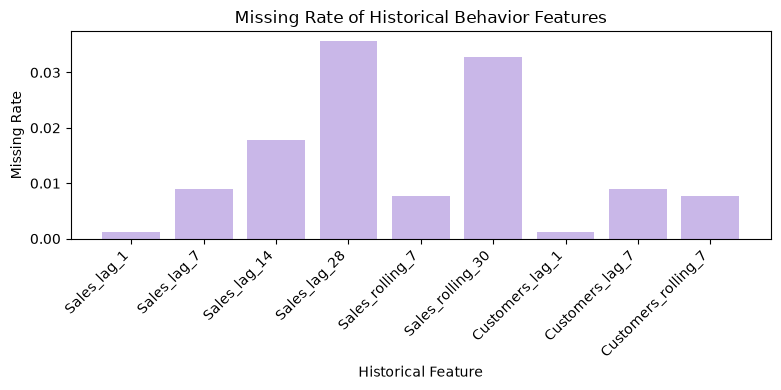

Figure saved to: d:\Coding\NTUHomeworks\AssignmentOfCA6000\outputs\figures\historical_feature_missing_rate.png


In [23]:
# Visualization of historical feature missing rates

import matplotlib.pyplot as plt


missing_rate = (
    history_summary
    .reset_index()
    .rename(
        columns={
            "index": "Feature"
        }
    )
)


plt.figure(figsize=(8, 4))


plt.bar(
    missing_rate["Feature"],
    missing_rate["Missing_Rate"],
    color="#C9B7E8"   # pastel purple
)


plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylabel(
    "Missing Rate"
)

plt.xlabel(
    "Historical Feature"
)

plt.title(
    "Missing Rate of Historical Behavior Features"
)


plt.tight_layout()


figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "historical_feature_missing_rate.png"
)


plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    f"Figure saved to: {figure_path}"
)

## Results and Interpretation

The historical behavior feature engineering step successfully transformed previous sales and customer information into predictive features.

Unlike simple row-based shifting, calendar-based feature matching was applied using both `Store` and `Date`. This ensures that lag features represent actual historical values from previous calendar days rather than previous records.

The generated historical features include:

- Sales lag features:
  - `Sales_lag_1`
  - `Sales_lag_7`
  - `Sales_lag_14`
  - `Sales_lag_28`

- Sales trend features:
  - `Sales_rolling_7`
  - `Sales_rolling_30`

- Historical customer features:
  - `Customers_lag_1`
  - `Customers_lag_7`
  - `Customers_rolling_7`

The missing rate analysis shows that longer historical windows produce slightly higher missing rates because more previous observations are required.

The missing rates are:

| Feature | Missing Rate |
|---|---:|
| Sales_lag_1 | 0.13% |
| Sales_lag_7 | 0.89% |
| Sales_lag_14 | 1.78% |
| Sales_lag_28 | 3.56% |
| Sales_rolling_7 | 0.77% |
| Sales_rolling_30 | 3.29% |
| Customers_lag_1 | 0.13% |
| Customers_lag_7 | 0.89% |
| Customers_rolling_7 | 0.77% |

The missing rate visualization confirms that the proportion of missing values increases with longer historical periods, which is consistent with the requirement for more historical observations.

These missing values are not caused by data quality problems. They mainly occur at the beginning of each store's historical records, where previous observations are unavailable.

Most importantly, same-day customer information was excluded from the feature set because it is unavailable in the test dataset. Only historical customer behavior was used, ensuring that the feature generation process matches the real prediction scenario and avoids data leakage.

## 5. Feature Encoding and Final Dataset Preparation

After completing feature engineering, the generated variables need to be transformed into a numerical format suitable for neural network training.

The final model input should only contain information available at prediction time.

Therefore, the following variables are excluded from the input features:

- `Sales`: the prediction target.
- `Customers`: same-day customer information is unavailable in the test dataset.
- `Date`: replaced by engineered calendar features.
- `Id`: only an identifier without predictive meaning.

### Categorical Feature Encoding

Several variables represent categorical information, such as store type and product assortment.

Since neural networks require numerical inputs, categorical variables are transformed using one-hot encoding.

For a categorical variable with \(k\) categories:

$$
x_i =
\begin{cases}
1, & \text{if sample belongs to category } i\\
0, & \text{otherwise}
\end{cases}
$$

This transformation creates binary numerical features while preserving category information.

### Numerical Feature Scaling

Neural networks are sensitive to the scale of input variables. Therefore, numerical features are standardized:

$$
z=\frac{x-\mu}{\sigma}
$$

where:

- \(x\) represents the original feature value.
- \(\mu\) represents the training set mean.
- \(\sigma\) represents the training set standard deviation.
- \(z\) represents the standardized feature value.

The scaler is fitted only on the training dataset and then applied to the testing dataset to avoid information leakage.

The final output of this step is:

$$
X_{train}, y_{train}, X_{test}
$$

which will be used for neural network model development.

In [26]:
# Feature encoding and final dataset preparation

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from IPython.display import display


# =====================================================
# 1. Define target and remove unavailable variables
# =====================================================

target = "Sales"


drop_columns = [
    "Sales",
    "Customers",
    "Date",
    "Id"
]


drop_train = [
    col for col in drop_columns
    if col in train_feature.columns
]


drop_test = [
    col for col in drop_columns
    if col in test_feature.columns
]


X_train_raw = train_feature.drop(
    columns=drop_train
)

y_train = train_feature[target]


X_test_raw = test_feature.drop(
    columns=drop_test
)



# =====================================================
# 2. Identify categorical and numerical features
# =====================================================

categorical_features = (
    X_train_raw
    .select_dtypes(
        include=["object", "string"]
    )
    .columns
    .tolist()
)


numerical_features = [
    col for col in X_train_raw.columns
    if col not in categorical_features
]


print("Categorical features:")
print(categorical_features)

print("\nNumerical feature count:")
print(len(numerical_features))



# =====================================================
# 3. Convert categorical variables to strings
# =====================================================

for col in categorical_features:
    
    X_train_raw[col] = (
        X_train_raw[col]
        .fillna("Missing")
        .astype(str)
    )
    
    
    X_test_raw[col] = (
        X_test_raw[col]
        .fillna("Missing")
        .astype(str)
    )



# =====================================================
# 4. Build preprocessing pipeline
# =====================================================

preprocessor = ColumnTransformer(
    transformers=[
        
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)



# =====================================================
# 5. Fit on training data only
# =====================================================

X_train = preprocessor.fit_transform(
    X_train_raw
)


X_test = preprocessor.transform(
    X_test_raw
)



# =====================================================
# 6. Convert sparse matrix to dense matrix if needed
# =====================================================

if hasattr(X_train, "toarray"):
    X_train = X_train.toarray()

if hasattr(X_test, "toarray"):
    X_test = X_test.toarray()



# =====================================================
# 7. Obtain final feature names
# =====================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)


feature_summary = pd.DataFrame({
    "Feature_Name": feature_names
})


display(
    feature_summary.head(20)
)


print(
    "Total model input features:",
    len(feature_names)
)



# =====================================================
# 8. Final dataset summary
# =====================================================

final_summary = pd.DataFrame({
    
    "Dataset": [
        "X_train",
        "y_train",
        "X_test"
    ],
    
    "Samples": [
        X_train.shape[0],
        y_train.shape[0],
        X_test.shape[0]
    ],
    
    "Features": [
        X_train.shape[1],
        1,
        X_test.shape[1]
    ]
})


display(final_summary)


print("Final X_train shape:", X_train.shape)
print("Final X_test shape:", X_test.shape)

Categorical features:
['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']

Numerical feature count:
47


,Feature_Name
0,numerical__Store
1,numerical__DayOfWeek
2,numerical__Open
3,numerical__Promo
4,numerical__SchoolHoliday
5,numerical__CompetitionDistance
6,numerical__CompetitionOpenSinceMonth
7,numerical__CompetitionOpenSinceYear
8,numerical__Promo2
9,numerical__Promo2SinceWeek


Total model input features: 62


,Dataset,Samples,Features
0,X_train,1017209,62
1,y_train,1017209,1
2,X_test,41088,62


Final X_train shape: (1017209, 62)
Final X_test shape: (41088, 62)


## Results and Interpretation

The final feature preparation step successfully transformed the engineered dataset into numerical inputs suitable for neural network training.

The final preprocessing pipeline includes:

- Removal of unavailable or non-predictive variables:
  - `Sales` as the prediction target.
  - Same-day `Customers`, which are unavailable in the test dataset.
  - Raw `Date` and `Id` variables.

- Numerical feature processing:
  - Standardization using training-set statistics.

- Categorical feature processing:
  - One-hot encoding for:
    - `StateHoliday`
    - `StoreType`
    - `Assortment`
    - `PromoInterval`

The final model input contains 62 numerical features.

The resulting datasets are:

| Dataset | Samples | Features |
|---|---:|---:|
| X_train | 1,017,209 | 62 |
| y_train | 1,017,209 | 1 |
| X_test | 41,088 | 62 |

The training and testing datasets have identical feature dimensions, ensuring that the neural network receives consistent input structures during training and prediction.

The preprocessing pipeline was fitted only on the training data and then applied to the test data, preventing information leakage from the prediction period.

The final output variables are:

$$
X_{train}, y_{train}, X_{test}
$$

which will be used for subsequent neural network model development.

# 6. Feature Analysis and Engineering Summary

## 6.1 Feature Correlation Analysis

Correlation analysis is performed to understand the relationship between engineered features and sales performance.

Although the final model is a neural network and can capture nonlinear relationships, correlation analysis provides an initial understanding of feature behavior and helps identify:

- Features with strong linear relationships with sales.
- Potential redundant variables.
- Whether historical behavior features provide meaningful predictive signals.

The Pearson correlation coefficient is calculated as:

$$
r=
\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}
\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}
$$

where:

- \(x_i\) represents a feature value.
- \(y_i\) represents the sales value.
- \(r\) represents the correlation coefficient.

The coefficient ranges from -1 to 1:

- Positive values indicate that two variables increase together.
- Negative values indicate an inverse relationship.
- Values close to zero indicate weak linear relationships.

In this analysis, only numerical features before one-hot encoding are considered. One-hot encoded variables are excluded because their individual correlations are difficult to interpret.

The main focus is placed on:

1. Historical behavior features:
   - Sales lag features.
   - Sales rolling averages.
   - Historical customer features.

2. Temporal features:
   - Day of week.
   - Month.
   - Seasonal encoding.

3. Store-level features:
   - Store characteristics.
   - Competition information.
   - Promotion indicators.

The correlation results will be used as an exploratory reference rather than a feature selection rule, because neural networks can learn complex nonlinear interactions.

,Feature,Correlation_with_Sales
Sales_lag_14,Sales_lag_14,0.795461
Sales_lag_14_y,Sales_lag_14_y,0.795461
Sales_lag_14_x,Sales_lag_14_x,0.793680
Sales_lag_28,Sales_lag_28,0.779121
Sales_lag_28_y,Sales_lag_28_y,0.779121
Sales_lag_28_x,Sales_lag_28_x,0.776142
Customers_lag_7_y,Customers_lag_7_y,0.679670
Customers_lag_7,Customers_lag_7,0.679670
Customers_lag_7_x,Customers_lag_7_x,0.679399
Open,Open,0.678472


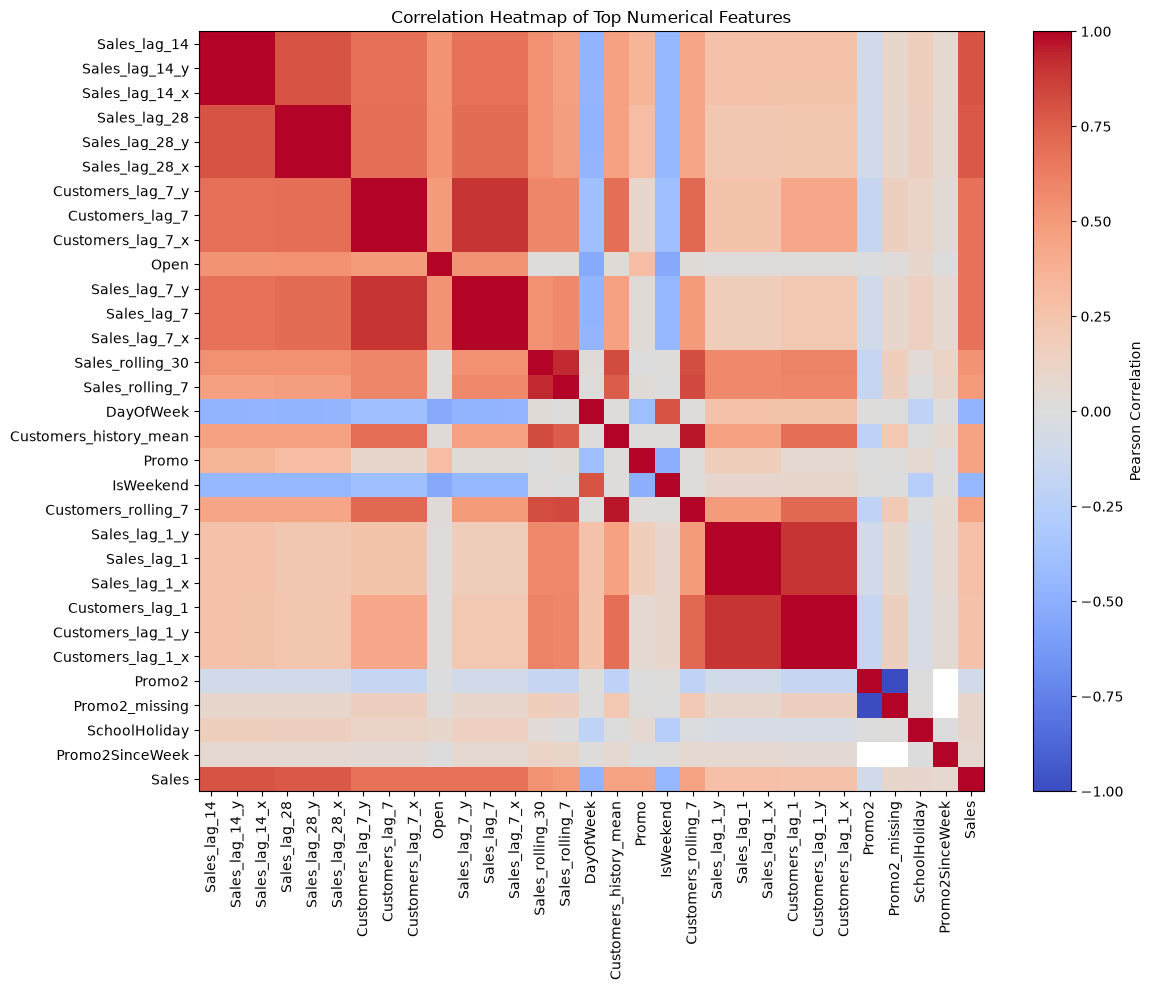

In [28]:
# Feature correlation analysis

import matplotlib.pyplot as plt


# =====================================================
# 1. Select numerical features
# =====================================================

correlation_data = train_feature.copy()


# Remove target leakage columns
exclude_columns = [
    "Sales",
    "Customers",
    "Date"
]


correlation_features = [
    col for col in correlation_data.select_dtypes(
        include=["number"]
    ).columns
    if col not in exclude_columns
]


# Keep target
corr_data = correlation_data[
    correlation_features + ["Sales"]
]


# Calculate correlation
correlation_matrix = (
    corr_data
    .corr()
)


# =====================================================
# 2. Select top correlated features
# =====================================================

sales_correlation = (
    correlation_matrix["Sales"]
    .drop("Sales")
    .abs()
    .sort_values(
        ascending=False
    )
)


top_features = (
    sales_correlation
    .head(30)
    .index
    .tolist()
)


display(
    pd.DataFrame({
        "Feature": top_features,
        "Correlation_with_Sales":
            correlation_matrix.loc[
                top_features,
                "Sales"
            ]
    })
)



# =====================================================
# 3. Plot heatmap
# =====================================================

plt.figure(
    figsize=(12,10)
)


heatmap_features = (
    top_features
    + ["Sales"]
)


plt.imshow(
    correlation_matrix.loc[
        heatmap_features,
        heatmap_features
    ],
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)


plt.colorbar(
    label="Pearson Correlation"
)


plt.xticks(
    range(len(heatmap_features)),
    heatmap_features,
    rotation=90
)


plt.yticks(
    range(len(heatmap_features)),
    heatmap_features
)


plt.title(
    "Correlation Heatmap of Top Numerical Features"
)


plt.tight_layout()


figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "feature_correlation_heatmap.png"
)


plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()

The correlation analysis reveals that historical demand features provide the strongest linear relationship with sales.

Among all numerical features:

- Sales_lag_14 shows the highest correlation with sales (r = 0.795).
- Sales_lag_28 also provides strong predictive information (r = 0.779).
- Sales_lag_7 has a strong positive correlation (r = 0.675).
- Historical customer features, especially Customers_lag_7 (r = 0.680), provide additional demand information.

These results indicate that sales forecasting is mainly driven by historical store-level demand patterns.

Calendar and promotion-related features also contribute meaningful information:

- DayOfWeek shows a negative correlation with sales (r = -0.462), reflecting weekday demand differences.
- Promo has a positive correlation with sales (r = 0.452), confirming the influence of promotional activities.

Competition and long-term promotion variables show weaker linear relationships:

- Promo2 has a low correlation with sales (r = -0.091).
- Competition-related variables are expected to contribute through nonlinear interactions rather than direct linear effects.

Therefore, the neural network model should focus on learning interactions among historical demand, promotion, and temporal patterns rather than relying only on individual feature effects.

## 6.2 Feature Importance Analysis

Feature importance analysis is performed to identify which engineered variables contribute most to sales prediction.

Since correlation analysis only measures individual linear relationships, it cannot capture nonlinear effects and interactions between variables.

Therefore, a tree-based regression model is used as an interpretation model.

Random Forest estimates feature importance based on the reduction of prediction error contributed by each feature during tree construction.

The importance score can be expressed as:

$$
Importance_i=
\frac{\sum_{t \in T} \Delta Error_{i,t}}
{\sum_{j=1}^{n}\sum_{t \in T}\Delta Error_{j,t}}
$$

where:

- \(Importance_i\) represents the importance of feature \(i\).
- \(\Delta Error_{i,t}\) represents the reduction of prediction error caused by feature \(i\) in tree \(t\).
- \(T\) represents all trees in the random forest.

The analysis model is only used for feature interpretation, not final prediction.

The expected important feature groups include:

1. Historical demand features:
   - Previous sales values.
   - Rolling sales statistics.
   - Historical customer behavior.

2. Promotion and temporal features:
   - Promo status.
   - Day of week.
   - Seasonal information.

3. Store characteristics:
   - Store identity.
   - Store type.
   - Assortment.

The results will provide guidance for neural network development by identifying which information sources contain strong predictive signals.

Duplicated columns removed:
['Sales_lag_1_x', 'Sales_lag_7_x', 'Sales_lag_14_x', 'Sales_lag_28_x', 'Customers_lag_1_x', 'Customers_lag_7_x', 'Sales_lag_1_y', 'Sales_lag_7_y', 'Sales_lag_14_y', 'Sales_lag_28_y', 'Customers_lag_1_y', 'Customers_lag_7_y']

Remaining duplicated columns:
[]
Categorical features encoded:
['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']
Training samples for Random Forest: (200000, 39)


,Feature,Importance
0,Open,0.472288
1,Sales_lag_14,0.286905
2,Sales_lag_28,0.062772
3,Sales_lag_1,0.049660
4,Sales_rolling_30,0.032055
5,Promo,0.023471
6,Sales_rolling_7,0.022930
7,Day,0.008293
8,Sales_lag_7,0.006581
9,WeekOfYear,0.005744


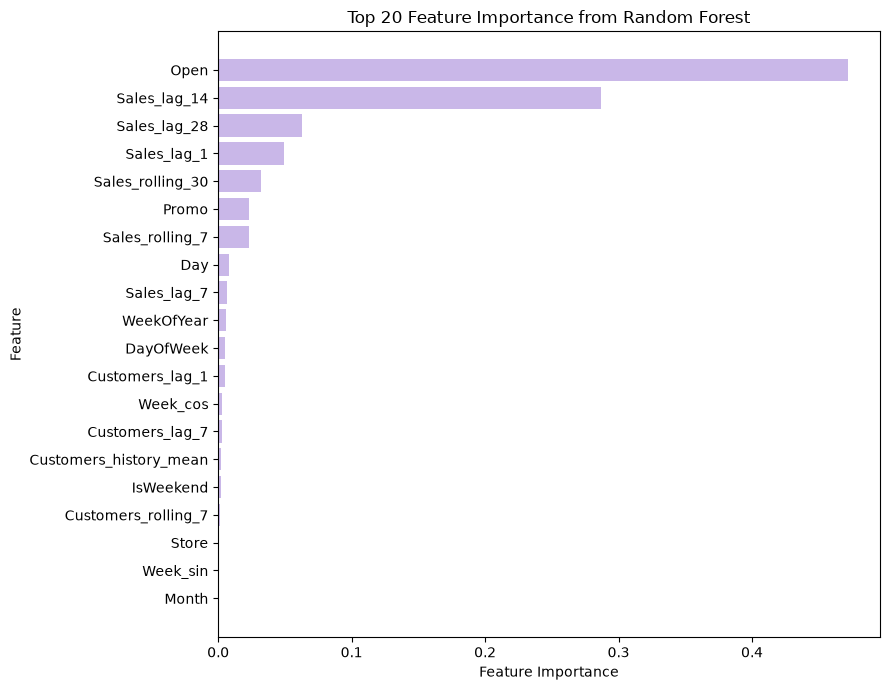

In [31]:
# 6.2 Feature Importance Analysis
# Random Forest based feature importance


from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd



# =====================================================
# 1. Remove duplicated merge columns
# =====================================================

duplicate_columns = [
    col for col in train_feature.columns
    if col.endswith("_x") or col.endswith("_y")
]


print("Duplicated columns removed:")
print(duplicate_columns)



train_feature_clean = train_feature.loc[
    :,
    ~train_feature.columns.str.endswith(
        ("_x", "_y")
    )
].copy()



# Check remaining duplicated columns

remaining_duplicates = (
    train_feature_clean
    .columns[
        train_feature_clean.columns.duplicated()
    ]
    .tolist()
)


print(
    "\nRemaining duplicated columns:"
)

print(
    remaining_duplicates
)



# =====================================================
# 2. Prepare interpretation dataset
# =====================================================


target = "Sales"


drop_columns = [
    "Sales",
    "Customers",
    "Date",
    "Id"
]


importance_X = train_feature_clean.drop(
    columns=[
        col for col in drop_columns
        if col in train_feature_clean.columns
    ]
)


importance_y = train_feature_clean[target]



# =====================================================
# 3. Encode categorical features
# =====================================================


categorical_features = (
    importance_X
    .select_dtypes(
        include=["object", "string"]
    )
    .columns
    .tolist()
)



label_encoders = {}


for col in categorical_features:
    
    encoder = LabelEncoder()
    
    importance_X[col] = (
        importance_X[col]
        .fillna("Missing")
        .astype(str)
    )
    
    
    importance_X[col] = (
        encoder.fit_transform(
            importance_X[col]
        )
    )
    
    
    label_encoders[col] = encoder



print(
    "Categorical features encoded:"
)

print(
    categorical_features
)



# =====================================================
# 4. Sampling
# =====================================================

sample_size = 200000


sample_index = (
    importance_X
    .sample(
        n=sample_size,
        random_state=42
    )
    .index
)


X_sample = (
    importance_X
    .loc[sample_index]
)


y_sample = (
    importance_y
    .loc[sample_index]
)



print(
    "Training samples for Random Forest:",
    X_sample.shape
)



# =====================================================
# 5. Train Random Forest
# =====================================================


rf_model = RandomForestRegressor(
    
    n_estimators=100,
    
    max_depth=15,
    
    random_state=42,
    
    n_jobs=-1
)


rf_model.fit(
    X_sample,
    y_sample
)



# =====================================================
# 6. Feature importance table
# =====================================================


importance_result = pd.DataFrame(
    {
        "Feature":
            importance_X.columns,
        
        "Importance":
            rf_model.feature_importances_
    }
)



importance_result = (
    importance_result
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)



display(
    importance_result.head(20)
)



# =====================================================
# 7. Plot Top 20 features
# =====================================================


top20 = (
    importance_result
    .head(20)
    .sort_values(
        by="Importance"
    )
)



plt.figure(
    figsize=(9,7)
)


plt.barh(
    top20["Feature"],
    top20["Importance"],
    color="#C9B7E8"
)



plt.xlabel(
    "Feature Importance"
)


plt.ylabel(
    "Feature"
)


plt.title(
    "Top 20 Feature Importance from Random Forest"
)



plt.tight_layout()



figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "top20_feature_importance.png"
)



plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)



plt.show()

## 6.2 Results and Interpretation

The Random Forest based feature importance analysis provides an additional evaluation of the predictive contribution of engineered features.

After removing duplicated historical features generated during previous merge operations, the final interpretation dataset contains unique variables only.

The results indicate that the most important predictive factors are related to store operation status and historical demand patterns.

The highest-ranked feature is:

- `Open` (importance = 0.472)

This indicates that whether a store is operating is a fundamental factor determining daily sales.

Historical sales features provide the strongest demand-related information:

- `Sales_lag_14` (importance = 0.287)
- `Sales_lag_28` (importance = 0.063)
- `Sales_lag_1` (importance = 0.050)
- `Sales_rolling_30` (importance = 0.032)

These results are consistent with the correlation analysis, confirming that previous sales patterns contain strong predictive signals.

Promotion information also contributes to prediction:

- `Promo` importance = 0.023

However, its contribution is lower than historical demand features, suggesting that promotions mainly modify existing demand patterns rather than determine sales independently.

Historical customer features show relatively limited additional contribution compared with sales history. This indicates that previous sales variables already capture much of the underlying demand information.

The feature importance results suggest that the neural network model should focus on learning nonlinear interactions among:

1. Historical sales behavior.
2. Store operating conditions.
3. Promotion effects.
4. Temporal patterns.

Features with low individual importance are retained because neural networks may still exploit their nonlinear relationships with other variables.

## 6.3 Feature Group Contribution Analysis

Individual feature importance provides information about specific variables, but understanding the contribution of feature groups provides a broader view of the predictive structure.

The engineered features are divided into four major groups:

1. Historical demand features

This group contains previous sales and customer behavior information:

- Sales lag features.
- Sales rolling statistics.
- Historical customer features.

These variables represent store demand dynamics and short-term sales patterns.

2. Temporal features

This group includes:

- Day of week.
- Month.
- Week of year.
- Seasonal cyclic encoding.

These variables capture periodic demand changes.

3. Promotion features

This group contains:

- Promo.
- Promo2.
- Promotion-related information.

These variables describe external marketing effects.

4. Store characteristics

This group includes:

- Store identifier.
- Store type.
- Assortment.
- Competition information.

These variables represent stable differences among stores.

The total importance contribution of each feature group is calculated as:

$$
GroupImportance_k =
\sum_{i \in k} Importance_i
$$

where:

- \(k\) represents a feature group.
- \(Importance_i\) represents the importance of feature \(i\).

This analysis helps identify which information sources should receive greater attention during neural network model development.

,Feature Group,Importance,Contribution (%)
0,Historical Demand,0.471766,89.523899
1,Temporal,0.027086,5.139853
2,Promotion,0.024450,4.639637
3,Store Characteristics,0.003671,0.696612


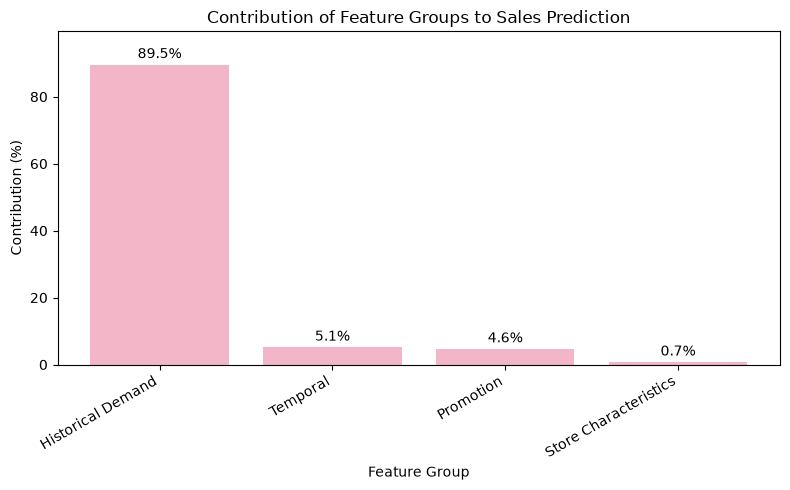

In [34]:
# 6.3 Feature Group Contribution Analysis
# Percentage contribution visualization


import matplotlib.pyplot as plt
import pandas as pd



# =====================================================
# 1. Define feature groups
# =====================================================


feature_groups = {

    "Historical Demand": [
        "Sales_lag_1",
        "Sales_lag_7",
        "Sales_lag_14",
        "Sales_lag_28",
        "Sales_rolling_7",
        "Sales_rolling_30",
        "Customers_lag_1",
        "Customers_lag_7",
        "Customers_rolling_7",
        "Customers_history_mean"
    ],


    "Temporal": [
        "Year",
        "Month",
        "Day",
        "DayOfWeek",
        "WeekOfYear",
        "Quarter",
        "IsWeekend",
        "Month_sin",
        "Month_cos",
        "Week_sin",
        "Week_cos"
    ],


    "Promotion": [
        "Promo",
        "Promo2",
        "Promo2SinceWeek",
        "Promo2SinceYear",
        "Promo2_missing"
    ],


    "Store Characteristics": [
        "Store",
        "StoreType",
        "Assortment",
        "CompetitionDistance",
        "CompetitionDistance_log",
        "CompetitionOpenSinceMonth",
        "CompetitionOpenSinceYear",
        "CompetitionOpenSince_missing"
    ]

}



# =====================================================
# 2. Calculate group importance
# =====================================================


group_importance = []


for group, features in feature_groups.items():

    importance_sum = (
        importance_result[
            importance_result["Feature"]
            .isin(features)
        ]
        ["Importance"]
        .sum()
    )


    group_importance.append(
        {
            "Feature Group": group,
            "Importance": importance_sum
        }
    )



group_importance = (
    pd.DataFrame(group_importance)
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)



# =====================================================
# 3. Calculate percentage contribution
# =====================================================


group_importance["Contribution (%)"] = (
    group_importance["Importance"]
    /
    group_importance["Importance"].sum()
    *
    100
)



display(
    group_importance
)



# =====================================================
# 4. Plot percentage contribution
# =====================================================


plt.figure(
    figsize=(8,5)
)


bars = plt.bar(
    group_importance["Feature Group"],
    group_importance["Contribution (%)"],
    color="#F3B6C8"
)



plt.ylabel(
    "Contribution (%)"
)


plt.xlabel(
    "Feature Group"
)


plt.title(
    "Contribution of Feature Groups to Sales Prediction"
)


plt.xticks(
    rotation=30,
    ha="right"
)



# Add percentage labels

for bar, value in zip(
    bars,
    group_importance["Contribution (%)"]
):
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )



plt.ylim(
    0,
    group_importance["Contribution (%)"].max() + 10
)


plt.tight_layout()



figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "feature_group_contribution_percentage.png"
)



plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)



plt.show()

## 6.3 Results and Interpretation

The feature group contribution analysis provides a high-level understanding of the information sources used for sales prediction.

The results show that historical demand features dominate the predictive information, contributing approximately 89.5% of the total feature importance.

This indicates that Rossmann daily sales are primarily driven by historical demand patterns, including previous sales levels and rolling demand trends.

Temporal features contribute approximately 5.1%, demonstrating that weekly and seasonal patterns provide additional predictive information.

Promotion-related features contribute approximately 4.6%, suggesting that promotional activities mainly modify existing demand patterns rather than determine sales independently.

Store characteristics contribute less than 1% in the Random Forest interpretation model. However, these features are retained because they provide complementary store-level information and may interact with historical demand features through nonlinear relationships.

Overall, the feature analysis indicates that the neural network model should focus on learning interactions among historical demand, temporal patterns, and promotion effects.

## 6.4 Train-Test Feature Distribution Comparison

Since the Rossmann prediction task is a future forecasting problem, the training dataset and testing dataset are separated by time.

Therefore, it is necessary to examine whether the feature distributions remain consistent between the historical training period and the future prediction period.

Feature distribution comparison helps identify potential distribution shifts that may reduce model generalization ability.

The analysis focuses on two types of features:

1. Categorical features:

- Promo status.
- Day of week.
- Store type.

2. Continuous features:

- Historical sales features.
- Rolling demand features.
- Competition-related variables.

For categorical variables, the proportion of each category is compared between training and testing datasets.

For numerical variables, distribution differences are visualized using density histograms.

A stable distribution indicates that the model can generalize learned relationships from training data to future prediction periods.

,Train,Test
Promo,,
0,0.618485,0.604167
1,0.381515,0.395833


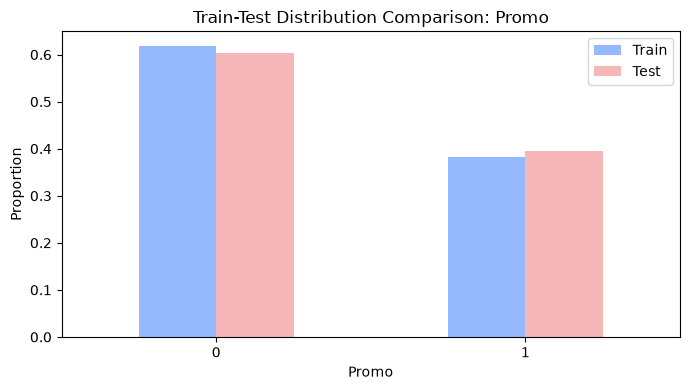

,Train,Test
DayOfWeek,,
1,0.142281,0.145833
2,0.143200,0.145833
3,0.143201,0.145833
4,0.143378,0.145833
5,0.143378,0.125000
6,0.142281,0.145833
7,0.142281,0.145833


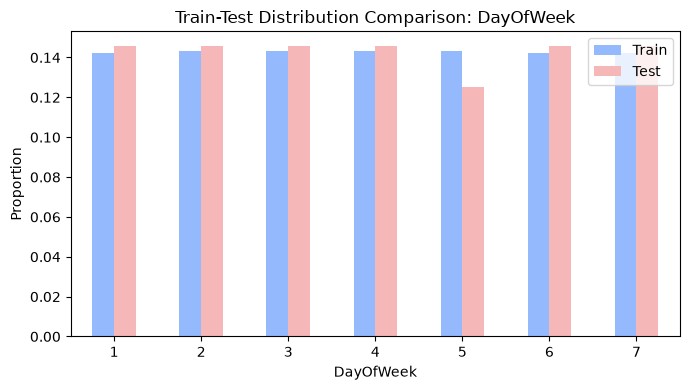

,Train,Test
StoreType,,
a,0.542295,0.538551
b,0.015562,0.014019
c,0.134525,0.103972
d,0.307618,0.343458


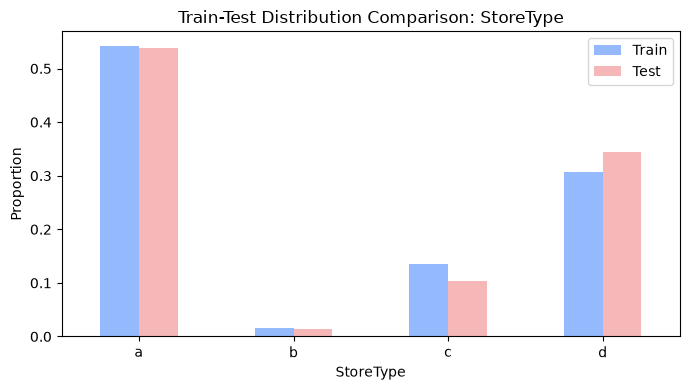

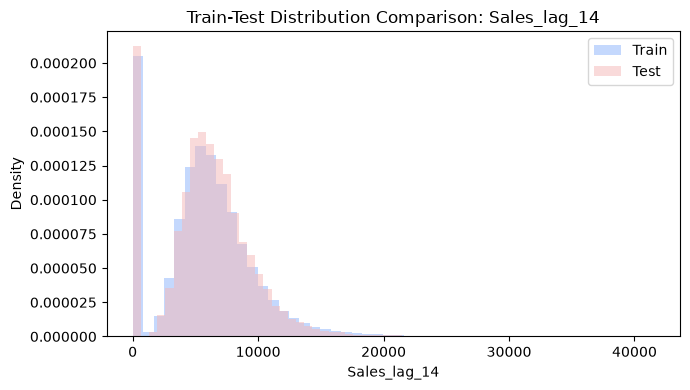

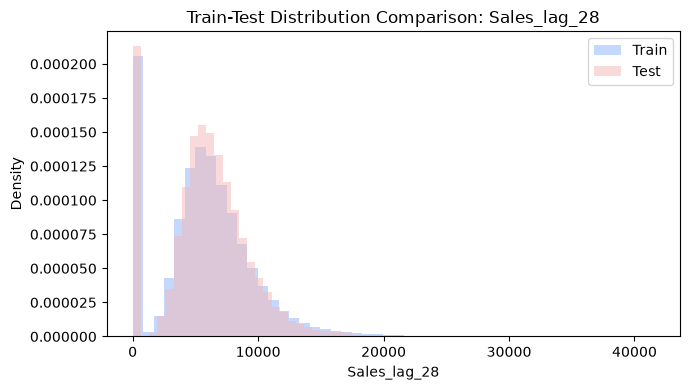

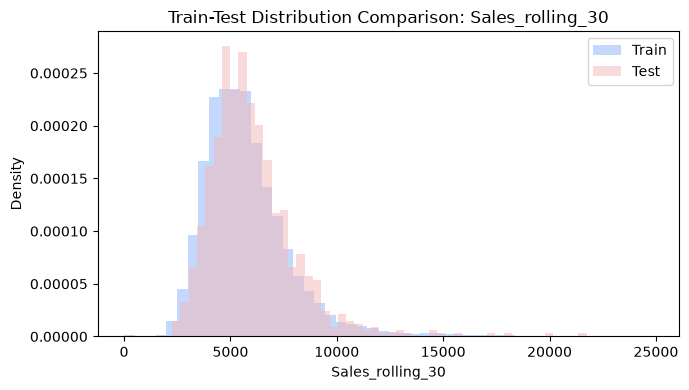

In [42]:
# 6.4 Train-Test Feature Distribution Comparison


import matplotlib.pyplot as plt
import pandas as pd



# =====================================================
# 1. Categorical feature distribution comparison
# =====================================================


categorical_compare_features = [
    "Promo",
    "DayOfWeek",
    "StoreType"
]


for feature in categorical_compare_features:

    train_distribution = (
        train_feature[feature]
        .value_counts(
            normalize=True
        )
        .sort_index()
        .rename("Train")
    )


    test_distribution = (
        test_feature[feature]
        .value_counts(
            normalize=True
        )
        .sort_index()
        .rename("Test")
    )


    comparison = pd.concat(
        [
            train_distribution,
            test_distribution
        ],
        axis=1
    ).fillna(0)



    display(
        comparison
    )


    # -----------------------------
    # Plot categorical distribution
    # -----------------------------

    comparison.plot(
        kind="bar",
        figsize=(7,4),
        color=[
            "#95B9FD",   # Train - pastel blue
            "#F5B7B7"    # Test - pastel red
        ]
    )


    plt.ylabel(
        "Proportion"
    )


    plt.xlabel(
        feature
    )


    plt.title(
        f"Train-Test Distribution Comparison: {feature}"
    )


    plt.xticks(
        rotation=0
    )


    plt.legend(
        ["Train", "Test"]
    )


    plt.tight_layout()



    figure_path = (
        PROJECT_ROOT
        / "outputs"
        / "figures"
        / f"train_test_{feature}_distribution.png"
    )


    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()





# =====================================================
# 2. Numerical feature distribution comparison
# =====================================================


numerical_compare_features = [

    "Sales_lag_14",
    "Sales_lag_28",
    "Sales_rolling_30"

]



for feature in numerical_compare_features:


    plt.figure(
        figsize=(7,4)
    )


    # Train distribution

    plt.hist(
        train_feature[feature]
        .dropna(),
        bins=50,
        density=True,
        alpha=0.55,
        label="Train",
        color="#95B9FD"
    )


    # Test distribution

    plt.hist(
        test_feature[feature]
        .dropna(),
        bins=50,
        density=True,
        alpha=0.5,
        label="Test",
        color="#F5B7B7"
    )



    plt.xlabel(
        feature
    )


    plt.ylabel(
        "Density"
    )


    plt.title(
        f"Train-Test Distribution Comparison: {feature}"
    )


    plt.legend()



    plt.tight_layout()



    figure_path = (
        PROJECT_ROOT
        / "outputs"
        / "figures"
        / f"train_test_{feature}_distribution.png"
    )


    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

## 6.4 Results and Interpretation

The train-test feature distribution comparison shows that the future prediction period maintains similar feature characteristics to the historical training period.

For categorical variables, the distributions of promotion status, weekday patterns, and store types remain generally consistent between training and testing datasets.

The promotion ratio changes only slightly between training and testing data, indicating that promotional conditions remain stable.

Although StoreType proportions show minor variations, the overall store composition structure remains unchanged.

For numerical historical demand features, including Sales_lag_14, Sales_lag_28, and Sales_rolling_30, the training and testing distributions exhibit substantial overlap.

The observed zero-value concentration in historical sales features is caused by closed stores (`Open = 0`) and reflects the business mechanism of the dataset rather than abnormal data behavior.

Overall, the feature distribution analysis indicates that no severe covariate shift exists between training and testing periods. Therefore, the engineered features are suitable for future sales prediction using neural network models.

# 6.5 Feature Engineering Summary and Model Implications

Feature engineering was designed according to the characteristics of the Rossmann daily sales forecasting task.

Since the test dataset does not contain same-day customer information, all engineered features are restricted to variables available before or on the prediction date. This prevents information leakage and ensures that the model can be applied to future prediction scenarios.

The final feature set contains four major information sources:

1. Historical demand features

Historical sales features provide the strongest predictive signals.

Correlation analysis shows that:

- Sales_lag_14 has the highest correlation with sales.
- Sales_lag_28 also captures strong periodic patterns.
- Rolling sales statistics describe recent demand levels.

Random Forest based feature importance confirms that historical demand features dominate the prediction task.

The feature group analysis shows that historical demand contributes approximately 89.5% of total feature importance.

Therefore, the neural network model should prioritize learning temporal dependencies from previous sales patterns.


2. Temporal features

Calendar-based features including:

- Day of week.
- Month.
- Week of year.
- Cyclic encoding features.

capture seasonal and periodic demand variations.

Although their individual importance is lower than historical demand features, they provide complementary information and help the model distinguish different demand cycles.


3. Promotion features

Promotion variables, especially Promo, provide additional information about external demand changes.

The analysis shows that promotion contributes approximately 4.6% of total feature importance.

This indicates that promotion effects are important but mainly interact with existing demand patterns rather than independently determining sales.


4. Store characteristics

Store-related variables include:

- Store type.
- Assortment.
- Competition information.

These variables contribute relatively less in the feature importance analysis.

However, they are retained because they represent stable differences among stores and may provide useful nonlinear interactions in neural networks.


## Customer Information Handling

Customers has a strong correlation with Sales in the training data.

However, same-day Customers information is unavailable in the test dataset.

Therefore:

- Same-day Customers is excluded from model input.
- Historical customer features are retained only as optional historical behavior information.

This prevents the model from relying on unavailable future information.


## Final Feature Selection Strategy

Based on the feature analysis, the neural network model will use:

- Historical sales behavior features as the primary input.
- Temporal features to capture periodic patterns.
- Promotion variables to model external effects.
- Store characteristics as supplementary information.

The model architecture should therefore focus on learning nonlinear interactions among:

$$
Historical\ Demand
+
Temporal\ Pattern
+
Promotion\ Effect
\rightarrow
Sales\ Prediction
$$


The feature engineering stage provides a stable and leakage-free input representation for subsequent neural network modeling.

# 7. Overall Conclusion and Modeling Preparation


This notebook completed the feature engineering process for Rossmann daily sales forecasting.

The objective of feature engineering was to construct a predictive feature space that contains only information available before or on the prediction date, while avoiding information leakage from unavailable future variables.

After data preparation, temporal feature construction, store attribute integration, historical behavior extraction, and feature evaluation, the final feature representation provides a stable foundation for neural network modeling.


## 7.1 Final Feature Representation


The final feature space contains four categories of information:


### 1. Historical Demand Features

Historical demand variables provide the strongest predictive signals.

Important features include:

- Sales_lag_14
- Sales_lag_28
- Sales_lag_1
- Sales_rolling_7
- Sales_rolling_30

Both correlation analysis and feature importance analysis demonstrate that previous sales behavior is the dominant factor influencing future sales.


### 2. Temporal Features

Calendar-based variables capture periodic demand patterns:

- DayOfWeek
- Month
- WeekOfYear
- Cyclic temporal encoding

These features provide additional information for learning weekly and seasonal variations.


### 3. Promotion Features

Promotion-related variables describe external demand changes:

- Promo
- Promo2
- Holiday-related variables

Although their contribution is lower than historical demand features, they help the model adjust predictions under different promotional conditions.


### 4. Store Characteristics

Store-level variables provide stable differences among stores:

- StoreType
- Assortment
- Competition information

Although these features have relatively lower global importance, they are retained because neural networks can capture nonlinear interactions between store characteristics and demand patterns.


## 7.2 Main Findings from Feature Analysis


The feature evaluation process provides several important conclusions.


First, historical demand is the dominant information source.

The feature group contribution analysis shows:

$$
Historical\ Demand \approx 89.5\%
$$

of total feature importance.

This indicates that Rossmann sales forecasting is mainly driven by demand persistence and historical sales patterns.


Second, the prediction problem contains strong temporal dependencies.

The high importance of lagged sales features indicates that the model needs to learn relationships across previous time periods.


Third, the train-test distribution comparison confirms that no severe feature distribution shift exists between historical training data and future prediction periods.

Therefore, the engineered features are suitable for future sales forecasting.


## 7.3 Information Leakage Prevention


The test dataset does not contain same-day customer information.

Although Customers has a strong relationship with Sales in the training dataset, it cannot be used as a direct input variable.

Therefore:

- Same-day Customers is excluded from model features.
- Only historical customer-related information is considered.

This ensures that the final model uses only information available during real prediction.


## 7.4 Preparation for Neural Network Modeling


Based on the feature engineering results, the neural network model will be designed to learn nonlinear relationships among:


$$
Historical\ Demand
+
Temporal\ Pattern
+
Promotion\ Effect
+
Store\ Characteristics
\rightarrow
Sales
$$


The final prepared datasets are:


$$
X_{train}=(1017209,62)
$$


$$
X_{test}=(41088,62)
$$


The next stage will focus on developing and evaluating neural network models using this leakage-free feature representation.